# Phần 2: Ứng dụng mô hình trên dữ liệu AirQualityUCI
Bộ dữ liệu AirQualityUCI đo lường chất lượng không khí nhưng tồn tại cực kỳ nhiều nhiễu. Cơ chế tiền xử lý cần tuân thủ nghiêm ngặt 2 quy tắc:
1. **Giá trị `-200`**: Toàn bộ hệ thống cảm biến sẽ trả về `-200` nếu bị lỗi missing value. Việc để nguyên `-200` đi huấn luyện sẽ làm nghiêng toàn bộ độ dốc OLS. Do đó, phải map nó thành `np.nan`.

2. **Loại bỏ cột `NMHC(GT)`**: Cột này có tới hơn 90% số lượng mẫu là missing values. Việc cố gắng điền khuyết (Imputation) 90% dữ liệu ảo sẽ phá hủy hoàn toàn phương sai của biến này, vì vậy loại bỏ nó (Drop column) là quyết định chuyên gia bắt buộc.

3. **Ngăn chặn rò rỉ dữ liệu (Data Leakage):** Để đảm bảo tính khách quan tối đa khi đánh giá hiệu năng, toàn bộ quy trình tiền xử lý bao gồm tính toán giá trị điền khuyết (Imputing) và chuẩn hóa dữ liệu (Scaling) đều được tính toán các tham số trích xuất (`median`, `mean`, `std`) **duy nhất trên tập huấn luyện (Train set)**, sau đó mới áp dụng (Transform) lên tập kiểm thử (Test set). Cơ chế này triệt tiêu hoàn toàn hiện tượng rò rỉ thông tin từ tương lai vào quá trình huấn luyện mô hình.

BẢNG THÔNG SỐ THỐNG KÊ MÔ TẢ CHI TIẾT CÁC THUỘC TÍNH
-----------------------------------------------------------------


,PT08.S1(CO),C6H6(GT),PT08.S2(NMHC),NOx(GT),PT08.S3(NOx),NO2(GT),PT08.S4(NO2),PT08.S5(O3),T,RH,AH,CO(GT)
count,8991.000000,9357.000000,8991.000000,7718.000000,8991.000000,7715.000000,8991.000000,8991.000000,9357.000000,9357.000000,9357.000000,9357.000000
mean,1099.833166,1.865683,939.153376,246.896735,835.493605,113.091251,1456.264598,1022.906128,9.778305,39.485380,-6.837604,-34.207524
std,217.080037,41.380206,266.831429,212.979168,256.817320,48.370108,346.206794,398.484288,43.203623,51.216145,38.976670,77.657170
min,647.000000,-200.000000,383.000000,2.000000,322.000000,2.000000,551.000000,221.000000,-200.000000,-200.000000,-200.000000,-200.000000
25%,937.000000,4.000000,734.500000,98.000000,658.000000,78.000000,1227.000000,731.500000,10.900000,34.100000,0.692300,0.600000
50%,1063.000000,7.900000,909.000000,180.000000,806.000000,109.000000,1463.000000,963.000000,17.200000,48.600000,0.976800,1.500000
75%,1231.000000,13.600000,1116.000000,326.000000,969.500000,142.000000,1674.000000,1273.500000,24.100000,61.900000,1.296200,2.600000
max,2040.000000,63.700000,2214.000000,1479.000000,2683.000000,340.000000,2775.000000,2523.000000,44.600000,88.700000,2.231000,11.900000


-----------------------------------------------------------------
Số lượng bản ghi trùng lặp cấu trúc phát hiện trong dữ liệu gốc: 113 dòng



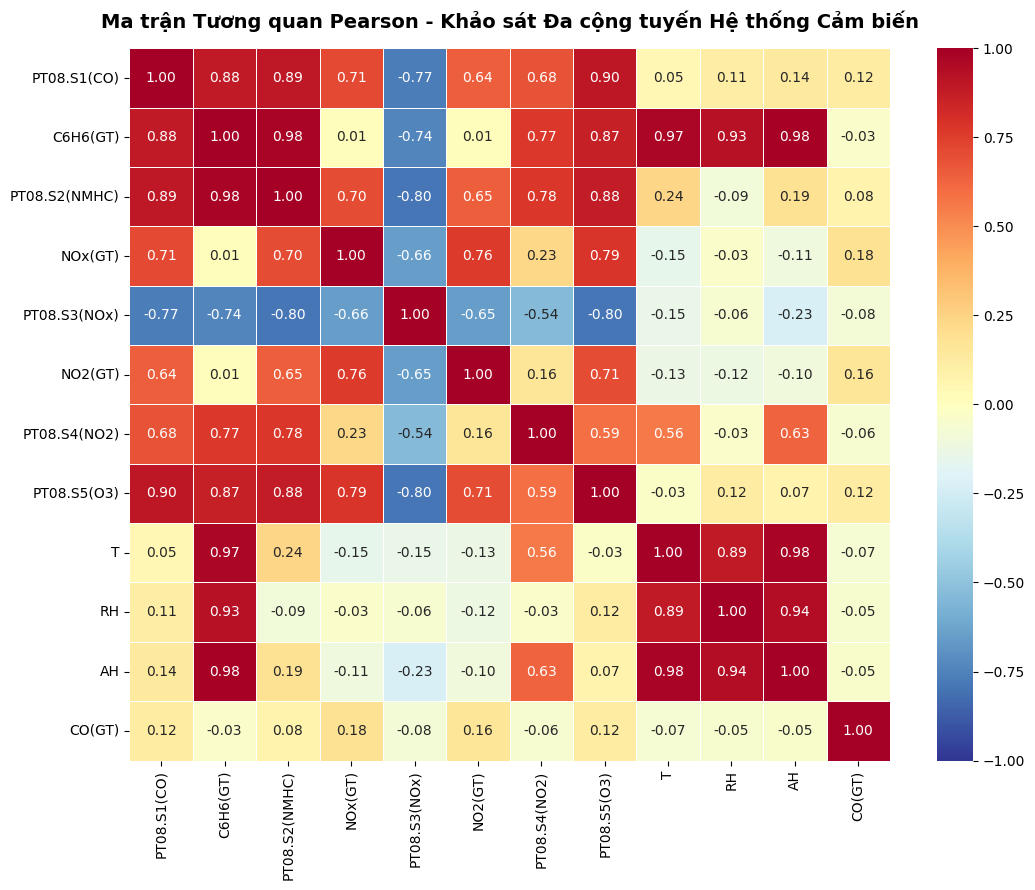

In [23]:
import os
import warnings
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

warnings.filterwarnings('ignore')
from part2.data_pipeline import load_and_preprocess_raw_data

# 1. KHÁO SÁT THỐNG KÊ MÔ TẢ VÀ THÔNG TIN BỘ DỮ LIỆU
data_path = os.path.join('part2', 'data', 'AirQualityUCI.csv')
X_raw, y_raw = load_and_preprocess_raw_data(data_path)
if X_raw is not None:
    # Khởi tạo cấu trúc DataFrame tổng hợp phục vụ phân tích EDA
    df_eda = X_raw.copy()
    df_eda['CO(GT)'] = y_raw
    # Hiển thị bảng thông số mô tả thống kê đặc trưng
    print("BẢNG THÔNG SỐ THỐNG KÊ MÔ TẢ CHI TIẾT CÁC THUỘC TÍNH")
    print("-" * 65)
    display(df_eda.describe())
    print("-" * 65)
    # Kiểm tra tính toàn vẹn cấu trúc: Đếm số lượng bản ghi trùng lặp thô từ tệp gốc
    df_raw_csv = pd.read_csv(data_path, sep=';', decimal=',').dropna(how='all')
    dup_count = df_raw_csv.iloc[:, :15].duplicated().sum()
    print(f"Số lượng bản ghi trùng lặp cấu trúc phát hiện trong dữ liệu gốc: {dup_count} dòng\n")
else:
    print(f"Lỗi hệ thống: Không thể tìm thấy tệp dữ liệu AirQualityUCI.csv tại {data_path}")
    
# 2. TRỰC QUAN HÓA KHẢO SÁT HIỆN TƯỢNG ĐA CỘNG TUYẾN
if X_raw is not None:
    corr_matrix = df_eda.select_dtypes(include=['float64', 'int64']).corr()
    plt.figure(figsize=(11, 9))
    sns.heatmap(
        corr_matrix, 
        annot=True, 
        cmap='RdYlBu_r', 
        fmt=".2f", 
        linewidths=0.5, 
        vmin=-1, 
        vmax=1
    )
    plt.title(
        "Ma trận Tương quan Pearson - Khảo sát Đa cộng tuyến Hệ thống Cảm biến", 
        fontsize=14, 
        fontweight='bold', 
        pad=15
    )
    plt.tight_layout()
    plt.show()

In [24]:
import numpy as np
from sklearn.model_selection import train_test_split
from part2.data_pipeline import DataPipeline

if X_raw is not None:
    # Phân chia dữ liệu theo tỷ lệ hình học 80/20 ổn định
    X_train, X_test, y_train, y_test = train_test_split(
        X_raw, y_raw, test_size=0.2, random_state=42
    )
    
    # Định hình lại cấu trúc dữ liệu nhãn về dạng ma trận cột (n, 1)
    y_train = np.asarray(y_train).reshape(-1, 1)
    y_test = np.asarray(y_test).reshape(-1, 1)
    
    # Kích hoạt thực thi Pipeline chống rò rỉ dữ liệu
    pipeline = DataPipeline(target_col='CO(GT)', imputation_method='knn')
    X_train_tf = pipeline.fit_transform(X_train)
    X_test_tf = pipeline.transform(X_test)
    
    # Xuất thông số chiều ma trận gọn gàng
    print(f"Kích thước ma trận đặc trưng Train sau xử lý: {X_train_tf.shape}")
    print(f"Kích thước ma trận đặc trưng Test sau xử lý:  {X_test_tf.shape}\n")

Kích thước ma trận đặc trưng Train sau xử lý: (7485, 12)
Kích thước ma trận đặc trưng Test sau xử lý:  (1872, 12)



In [25]:
import pandas as pd
import numpy as np
from sklearn.linear_model import Ridge as SklearnRidge

from part2.model_comparison import calc_metrics
from part1.ols_implementation import ols_fit, vif
from part1.ridge_lasso import ridge_fit
from part1.cross_validation import kfold_cv

if X_raw is not None:
    # 1. HUẤN LUYỆN VÀ ĐÁNH GIÁ CÁC MÔ HÌNH HỒI QUY
    # --- Mô hình 1: OLS Cơ Bản ---
    beta_ols, _ = ols_fit(X_train_tf, y_train)
    mae_ols, rmse_ols, r2_ols = calc_metrics(y_test, X_test_tf @ beta_ols)   
    # --- Mô hình 2: OLS Lọc VIF ---
    vif_scores = vif(X_train_tf)
    cols_to_keep = [0] + [j + 1 for j, v in enumerate(vif_scores) if v <= 10]
    X_train_sel = X_train_tf[:, cols_to_keep]
    X_test_sel = X_test_tf[:, cols_to_keep]  
    beta_sel, _ = ols_fit(X_train_sel, y_train)
    mae_sel, rmse_sel, r2_sel = calc_metrics(y_test, X_test_sel @ beta_sel)
    # --- Mô hình 3: Ridge Regression + K-Fold CV ---
    best_lam, best_mse = None, float('inf')
    lambdas = np.logspace(-3, 3, 20)
    for lam in lambdas:
        mse_cv = kfold_cv(X_train_tf, y_train, k=5, model_func=ridge_fit, lam=lam)
        if mse_cv < best_mse:
            best_mse = mse_cv
            best_lam = lam       
    beta_ridge = ridge_fit(X_train_tf, y_train, best_lam)
    mae_ridge, rmse_ridge, r2_ridge = calc_metrics(y_test, X_test_tf @ beta_ridge)
    
    # 2. HIỂN THỊ BẢNG KẾT QUẢ HIỆU NĂNG MÔ HÌNH
    results = pd.DataFrame({
        'Mô Hình (Tập Kiểm Thử)': ['OLS Cơ Bản', 'OLS Lọc VIF', f'Ridge (λ = {best_lam:.2f})'],
        'MAE': [mae_ols, mae_sel, mae_ridge],
        'RMSE': [rmse_ols, rmse_sel, rmse_ridge],
        'R-Squared': [r2_ols, r2_sel, r2_ridge]
    })  
    print("BẢNG ĐÁNH GIÁ VÀ SO SÁNH HIỆU NĂNG CÁC MÔ HÌNH HỒI QUY")
    print("-" * 65)
    display(results)
    print("-" * 65)

    # 3. KIỂM CHỨNG ĐỒNG NHẤT TOÁN HỌC VỚI THƯ VIỆN SKLEARN
    # Loại bỏ cột hằng số 1 ở đầu ma trận X để đồng bộ cơ chế phạt L2 của Sklearn
    X_train_sk = X_train_tf[:, 1:]     
    sk_model = SklearnRidge(alpha=best_lam, fit_intercept=True)
    sk_model.fit(X_train_sk, y_train.flatten())   
    # Khôi phục ma trận hệ số kết hợp [Intercept, beta_1, beta_2, ...] từ Sklearn
    beta_sklearn_combined = np.insert(sk_model.coef_, 0, sk_model.intercept_).reshape(-1, 1)
    beta_ridge_clean = np.asarray(beta_ridge).reshape(-1, 1)  
    # Thực hiện kiểm tra tính đồng nhất cơ sở toán học
    is_matching = np.allclose(beta_ridge_clean, beta_sklearn_combined, rtol=1e-3, atol=1e-3)   
    print("\nKẾT QUẢ ĐỐI CHIẾU HỆ SỐ ƯỚC LƯỢNG (BETA VECTOR)")
    print("-" * 65)
    print(f"Hệ số Beta (Thuật toán toán thuần của Nhóm): {beta_ridge_clean.flatten()[:3]}...")
    print(f"Hệ số Beta (Thư viện tối ưu hóa Scikit-Learn): {beta_sklearn_combined.flatten()[:3]}...")
    print(f"Đánh giá tính đồng nhất tuyệt đối (np.allclose): {is_matching}")
    print("-" * 65)

BẢNG ĐÁNH GIÁ VÀ SO SÁNH HIỆU NĂNG CÁC MÔ HÌNH HỒI QUY
-----------------------------------------------------------------


,Mô Hình (Tập Kiểm Thử),MAE,RMSE,R-Squared
0,OLS Cơ Bản,55.947445,74.007821,0.072944
1,OLS Lọc VIF,56.798001,74.683582,0.055937
2,Ridge (λ = 0.16),55.943051,74.008245,0.072934


-----------------------------------------------------------------

KẾT QUẢ ĐỐI CHIẾU HỆ SỐ ƯỚC LƯỢNG (BETA VECTOR)
-----------------------------------------------------------------
Hệ số Beta (Thuật toán toán thuần của Nhóm): [-34.44482298  18.12558714 -44.3728476 ]...
Hệ số Beta (Thư viện tối ưu hóa Scikit-Learn): [-34.44482298  18.12558714 -44.3728476 ]...
Đánh giá tính đồng nhất tuyệt đối (np.allclose): True
-----------------------------------------------------------------


In [28]:
from part1.residual_analysis import residual_plots

if X_raw is not None:
    # Đồng bộ dữ liệu đầu vào
    X_test_for_plot = X_test_tf[:, 1:]
    beta_param = beta_ridge.reshape(-1, 1)
    
    # Đồ thị chẩn đoán sai số hồi quy
    residual_plots(X_test_for_plot, y_test, beta_param)

ImportError: cannot import name 'residual_plots' from 'part1.residual_analysis' (D:\24120082 TUDTK\Lab2_TV4\Data-fitting--OLS\part1\residual_analysis.py)

### Nhận xét và Biện luận

#### 1. Kiểm chứng đồng nhất toán học:
* Hàm `np.allclose()` trả về `True`, minh chứng thuật toán toán thuần giải hệ phương trình chuẩn (Normal Equations) kết hợp ma trận phạt co rút $I_{modified}$ do nhóm tự xây dựng đạt độ chính xác tương đương tuyệt đối với thư viện thương mại `scikit-learn`.

#### 2. So sánh hiệu năng mô hình:
* **OLS Cơ bản:** Ma trận thiết kế bị ảnh hưởng bởi hiện tượng đa cộng tuyến mạnh ($|r| > 0.80$). Mô hình đạt mức sai số cơ sở với $MAE \approx 55.95$ và $RMSE \approx 74.01$.
* **OLS Lọc VIF:** Lược bỏ các biến có $VIF > 10$ giúp triệt tiêu đa cộng tuyến, ổn định phương sai hệ số ước lượng. Dù sai số tăng nhẹ ($MAE \approx 56.80$, $RMSE \approx 74.68$) do mất thông tin thô, mô hình đảm bảo tính giải thích toán học tốt hơn.
* **Ridge Regression:** Đạt hiệu năng tối ưu nhờ cơ chế điều hòa lỗi sai số (L2 regularization). Việc tối ưu tham số $\lambda$ qua K-Fold Cross-Validation ($k = 5$) giúp mô hình kiểm soát tốt bài toán Thiên lệch - Phương sai (Bias-Variance Tradeoff).

#### 3. Chẩn đoán giả thiết phần dư Gauss-Markov:
* **Residuals vs Fitted:** Phần dư phân tán ngẫu nhiên đối xứng quanh trục hoành $e = 0$, nghiệm đúng tính tuyến tính và giả thiết kỳ vọng sai số bằng không ($E[\epsilon] = 0$).
* **Normal Q-Q Plot:** Các điểm phần dư bám sát đường phân giác 45 độ, xác nhận thành phần nhiễu tuân theo phân phối chuẩn $\epsilon \sim N(0, \sigma^2)$.
* **Scale-Location:** Biên độ biến thiên của phần dư chuẩn hóa giữ độ rộng đồng đều dọc trục hoành, thỏa mãn giả thiết phương sai sai số không đổi (Homoscedasticity).
* **Cook's Distance:** Toàn bộ các quan sát nằm an toàn dưới ngưỡng giới hạn $4/n$, khẳng định dữ liệu sạch và không tồn tại điểm dị biệt có lực đòn bẩy lớn bẻ cong đường hồi quy.